## Logistic Regression for Cancer Diagnosis

#### **Model Representation**: In logistic regression, we represent the relationship between the independent variables $( X )$ and the binary dependent variable $( Y )$ using the logistic function. The logistic function is defined as:

   $ P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \ldots + \beta_n X_n)}}$

   Where:
   - $( P(Y=1|X) )$ is the probability that $( Y )$ is equal to 1 given $( X )$.
   - $( \beta_0, \beta_1, \ldots, \beta_n )$ are the coefficients of the model.
   - $( X_1, X_2, \ldots, X_n )$ are the independent variables.

### ***Import required dependecies***

In [ ]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Specify the directory where your files are located in Google Drive
directory = '/content/drive/My Drive/Colab Notebooks/breast_cancer_bd.csv'  # Update this to your path

# List all files in the specified directory
for dirname, _, filenames in os.walk(directory):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split #split the data as training set and testing set for analysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report #Libraries for analysis of our model performance
from sklearn.linear_model import LogisticRegression #The model used in this notebook

## Read csv file


In [ ]:
data = pd.read_csv(directory)
data.head(15)

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


## Preprocessing

### General Understanding

In [ ]:
data = data.drop('Sample code number', axis=1) # as this acts as a serial no. and dosent have much relation with the data

In [ ]:
data.info() #Gives the summary of our pandas dataframe, summary->datatype,non-null values of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump Thickness              699 non-null    int64 
 1   Uniformity of Cell Size      699 non-null    int64 
 2   Uniformity of Cell Shape     699 non-null    int64 
 3   Marginal Adhesion            699 non-null    int64 
 4   Single Epithelial Cell Size  699 non-null    int64 
 5   Bare Nuclei                  699 non-null    object
 6   Bland Chromatin              699 non-null    int64 
 7   Normal Nucleoli              699 non-null    int64 
 8   Mitoses                      699 non-null    int64 
 9   Class                        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [ ]:
data.describe() # Gives statistical measures of our data

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
data['Bare Nuclei'].unique() # finds unique values in each column

array(['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6'],
      dtype=object)

### Cleaning the data,Correcting wrong data entries,Filling empty cells

In [ ]:
from sklearn.impute import SimpleImputer

# Create an imputer for mean imputation
imputer = SimpleImputer(strategy='mean')

# Convert 'Bare Nuclei' to numeric and impute missing values in one step
data['Bare Nuclei'] = pd.to_numeric(data['Bare Nuclei'], errors='coerce')
data['Bare Nuclei'] = imputer.fit_transform(data[['Bare Nuclei']])

# Display the info of the DataFrame
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump Thickness              699 non-null    int64  
 1   Uniformity of Cell Size      699 non-null    int64  
 2   Uniformity of Cell Shape     699 non-null    int64  
 3   Marginal Adhesion            699 non-null    int64  
 4   Single Epithelial Cell Size  699 non-null    int64  
 5   Bare Nuclei                  699 non-null    float64
 6   Bland Chromatin              699 non-null    int64  
 7   Normal Nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


Filling empty spaces with median values, median here is same as median in statistics

In [ ]:
data['Bare Nuclei'] = data['Bare Nuclei'].fillna(data['Bare Nuclei'].median())

In [ ]:
X = data['Class']
y = data.drop('Class', axis=1)

stratify allows you to maintain the same distribution of classes in both subsets, which can lead to more reliable and valid results during model evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)

In [ ]:
lr = LogisticRegression()#default threshold = 0.5
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)

Accuracy: 0.97

Confusion Matrix:
 [[142   2]
 [  5  61]]


Classification Report:
               precision    recall  f1-score   support

           2       0.97      0.99      0.98       144
           4       0.97      0.92      0.95        66

    accuracy                           0.97       210
   macro avg       0.97      0.96      0.96       210
weighted avg       0.97      0.97      0.97       210



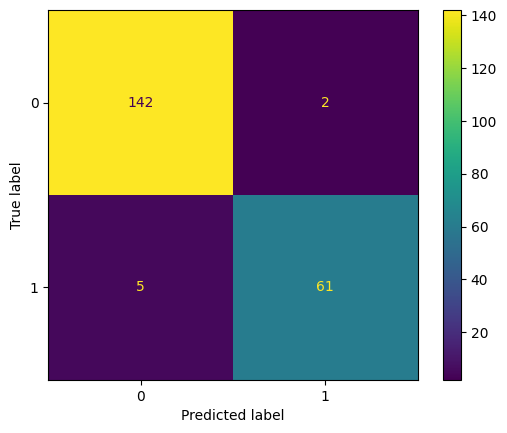

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}\n')

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Display confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
print("\n")
# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
